In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from scipy import stats
from imblearn.under_sampling import RandomUnderSampler


In [ ]:
df = pd.read_csv('/creditcard (1).csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import pandas as pd
# df = pd.read_csv('/content/drive/My Drive/Faroha/creditcard.csv')
# df.head()

In [ ]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [ ]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
scaler = StandardScaler()
df[['scaled_time', 'scaled_amount']] = scaler.fit_transform(df[['Time', 'Amount']])
df.drop(['Time', 'Amount'], axis=1, inplace=True)
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_time,scaled_amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996583,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996583,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-1.996562,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-1.996562,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-1.996541,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,1.641931,-0.350151
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,1.641952,-0.254117
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,1.641974,-0.081839
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,1.641974,-0.313249


In [ ]:
df = df.drop('Class', axis=1).assign(Class=df['Class'])
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,scaled_time,scaled_amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,-1.996583,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.996583,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,-1.996562,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,-1.996562,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-1.996541,-0.073403,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,1.641931,-0.350151,0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,1.641952,-0.254117,0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,1.641974,-0.081839,0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,1.641974,-0.313249,0


In [ ]:
df= df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [ ]:
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#EDA#

In [ ]:
# Handle outliers using Z-score method
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).all(axis=1)  # Identify outliers (Z-score > 3)
print(f"Number of outlier rows: {outliers.sum()}")



Number of outlier rows: 0


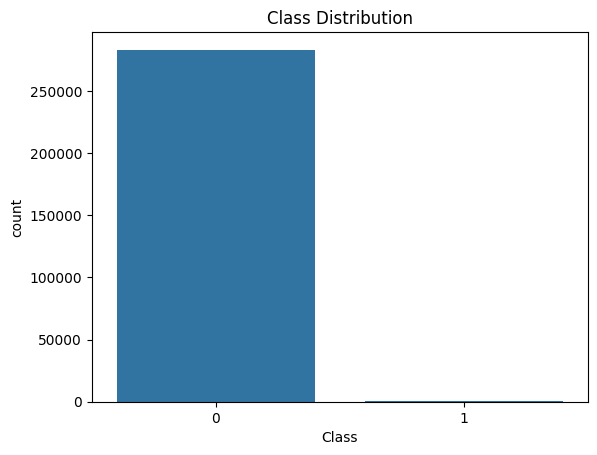

Fraudulent transactions: 0.1667%


In [ ]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

# Percentage of fraud cases
fraud_percent = df['Class'].value_counts(normalize=True)[1] * 100
print(f"Fraudulent transactions: {fraud_percent:.4f}%")


In [ ]:
minority_class_count = y.value_counts()[1]
majority_class_target = minority_class_count * 4
sampling_strategy = {0: min(majority_class_target, y.value_counts()[0]), 1: minority_class_count}

under_sampler = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = under_sampler.fit_resample(X, y)

print("Class distribution after under-sampling:\n", pd.Series(y_resampled).value_counts())


Class distribution after under-sampling:
 Class
0    1892
1     473
Name: count, dtype: int64


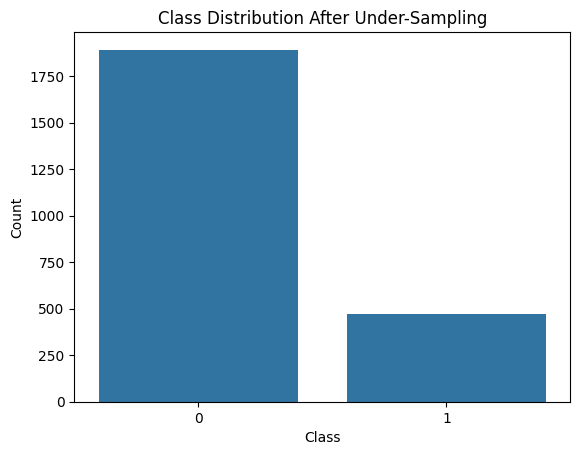

In [ ]:
sns.countplot(x=y_resampled)
plt.title("Class Distribution After Under-Sampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


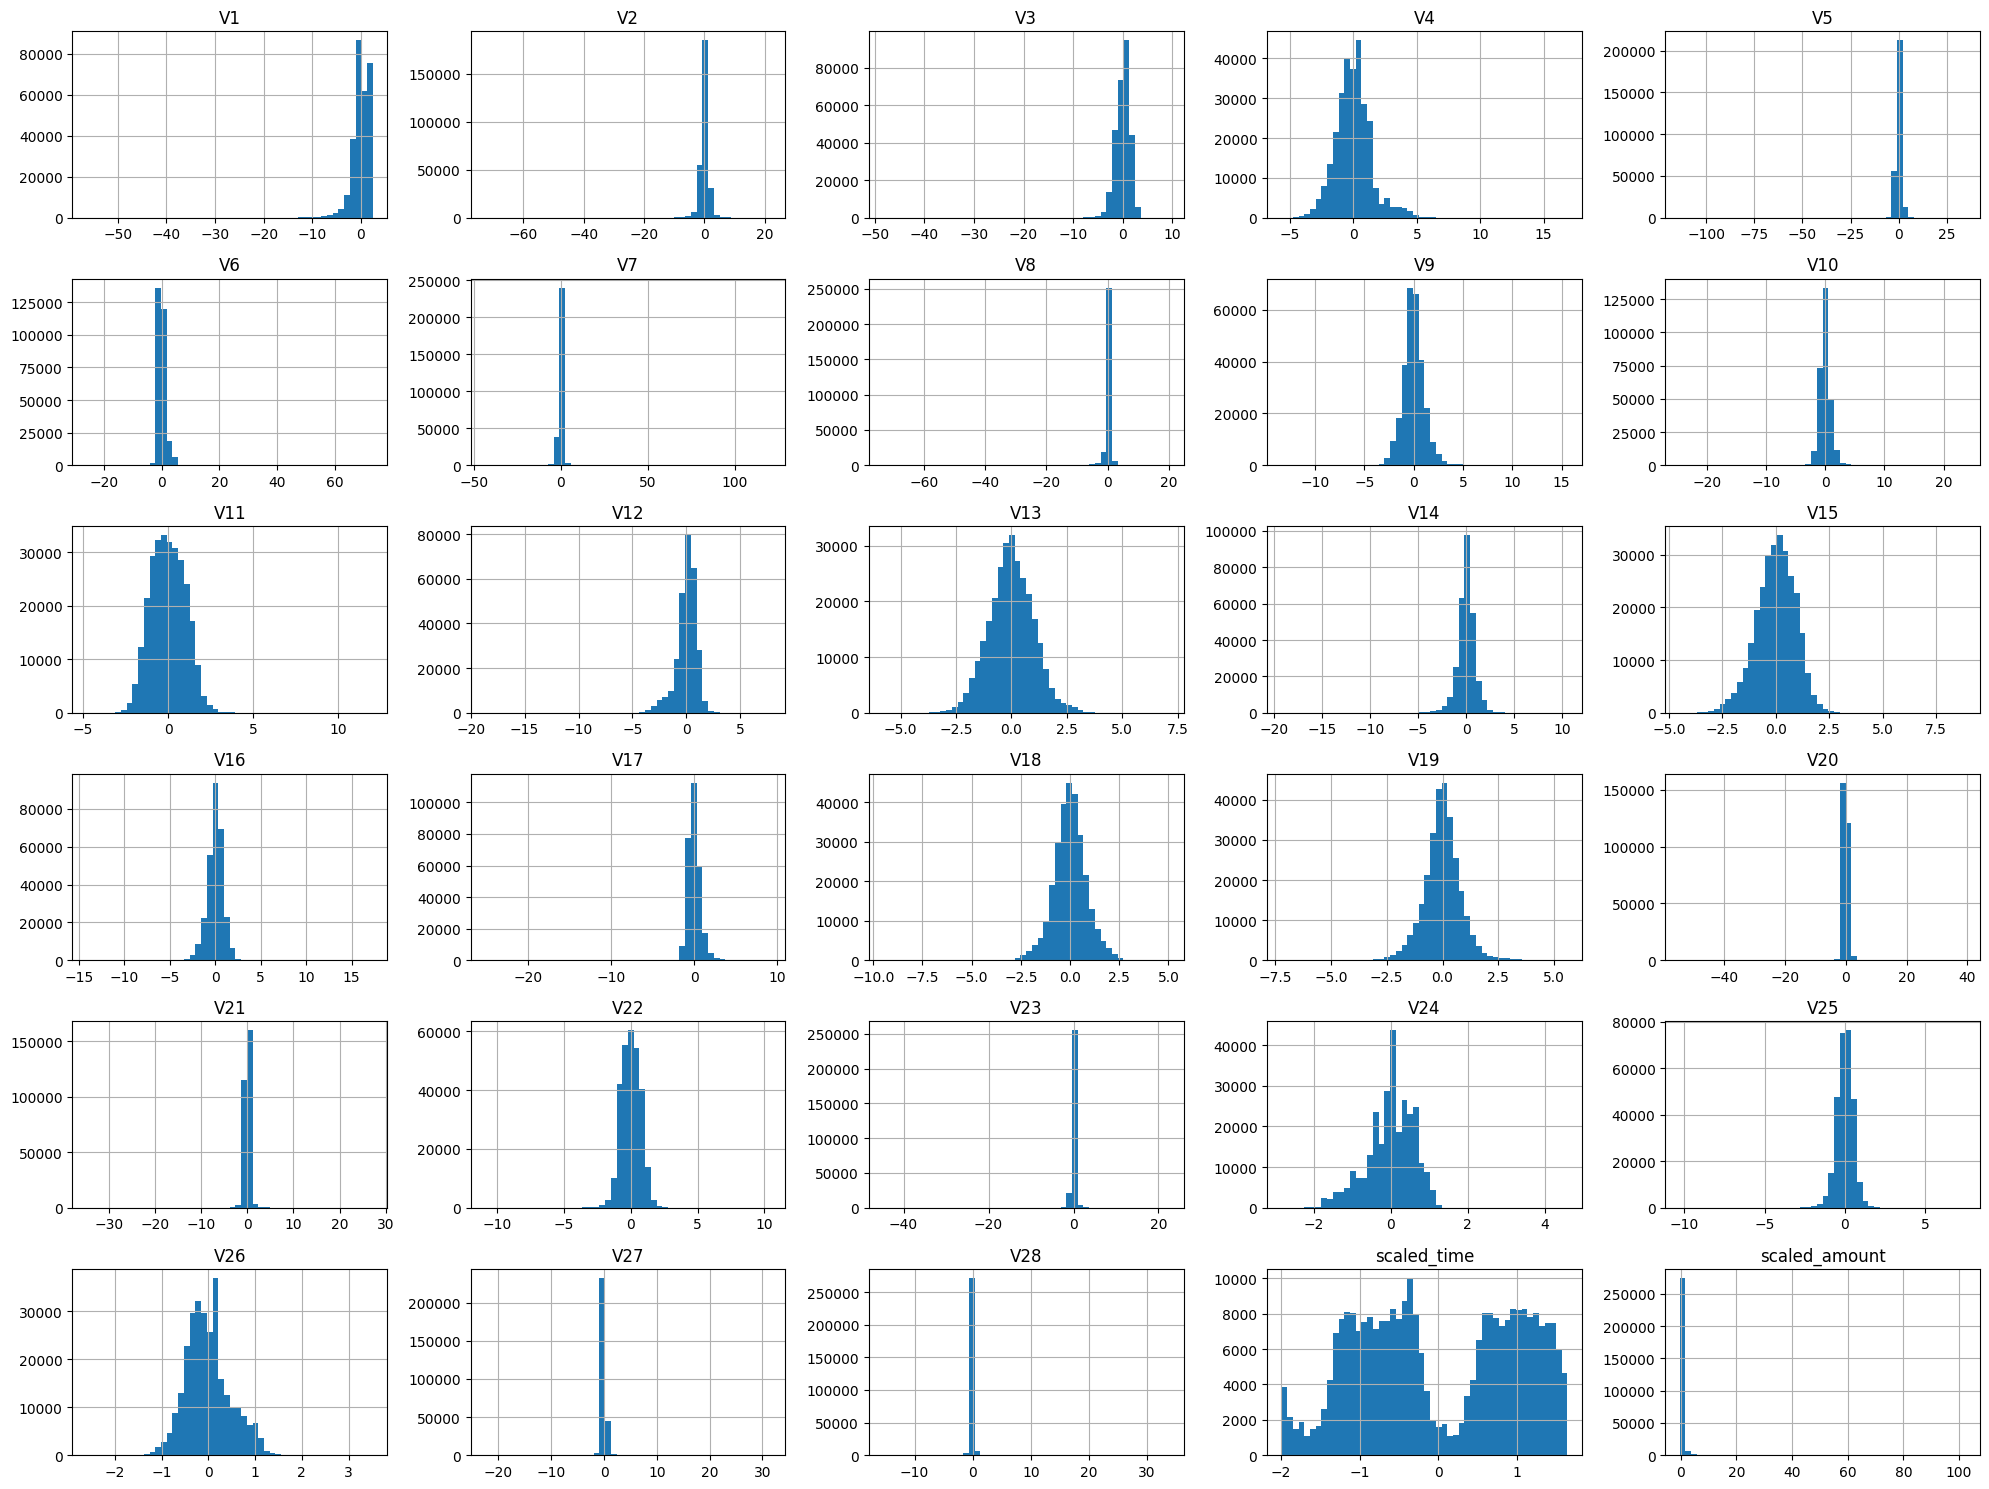

In [ ]:
df.drop('Class', axis=1).hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

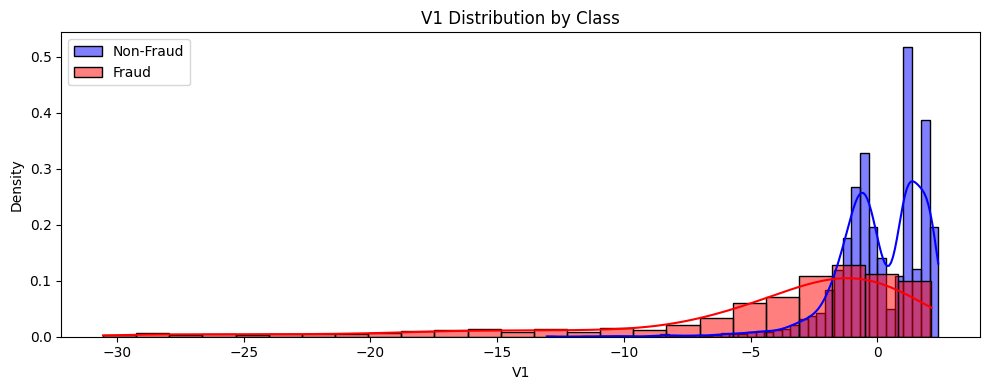

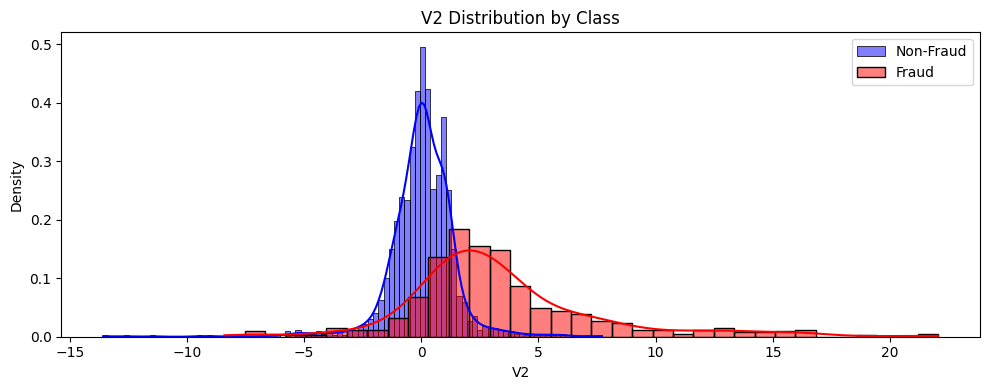

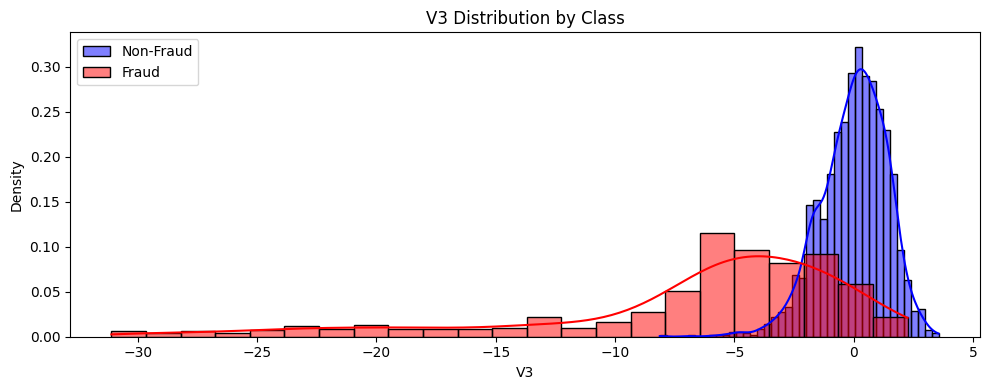

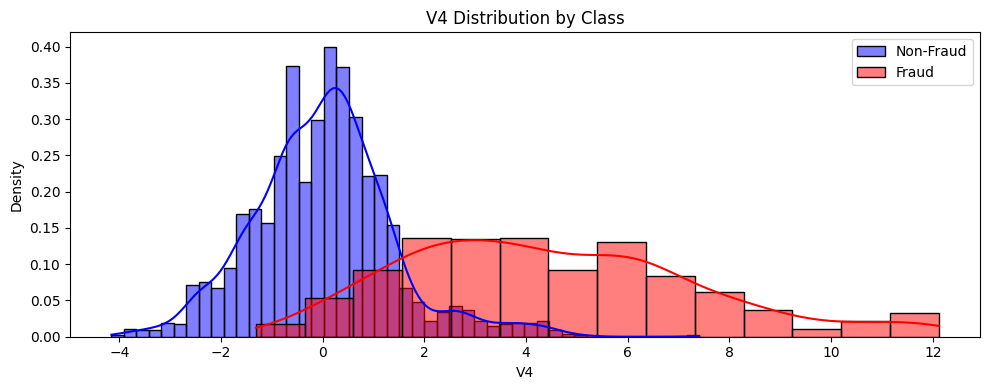

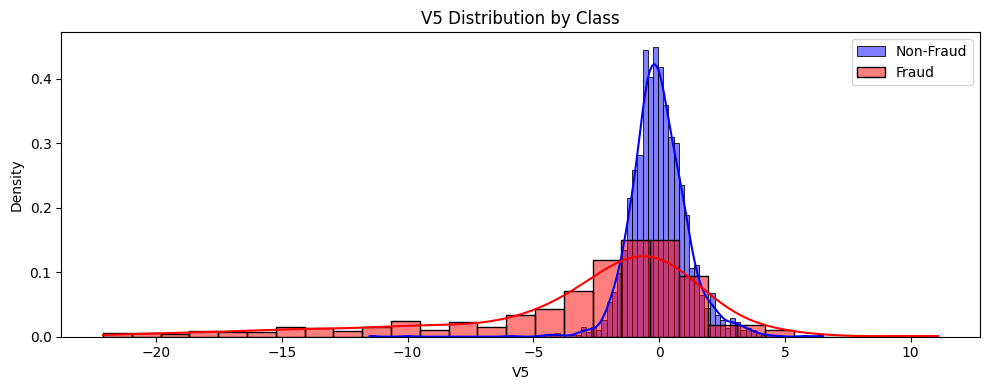

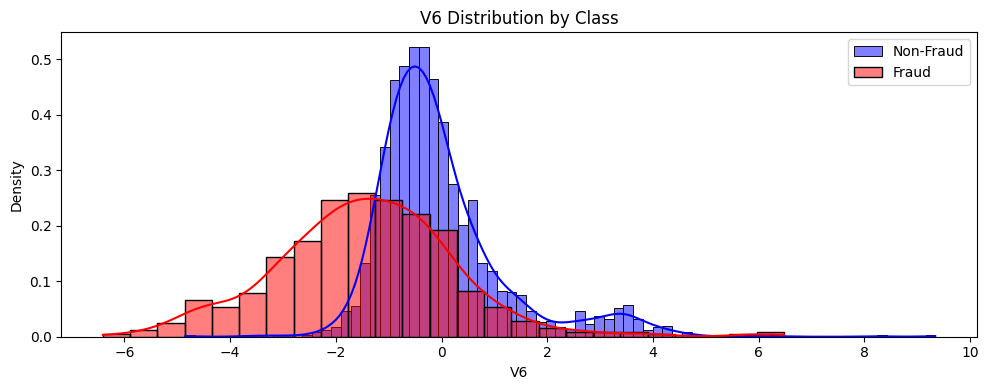

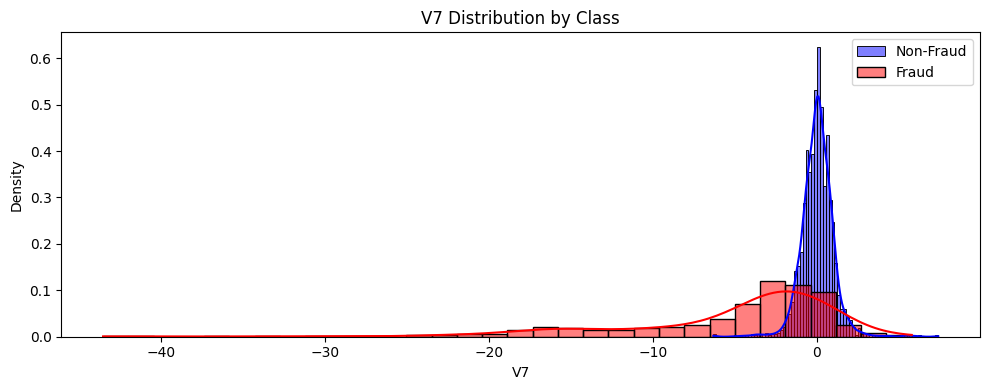

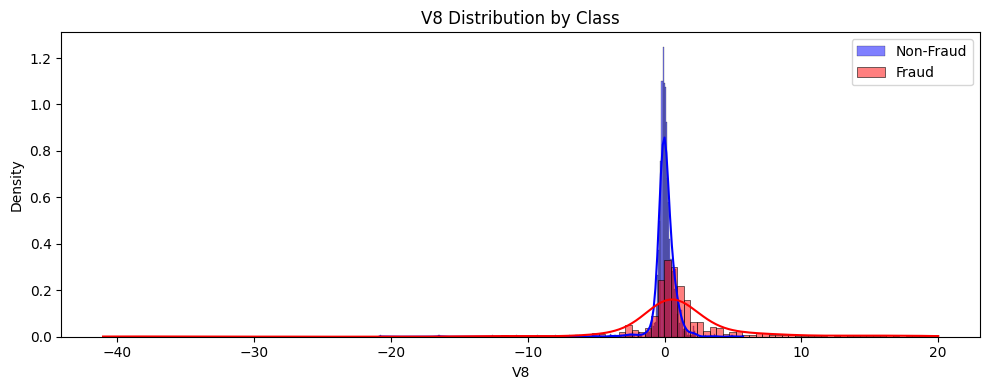

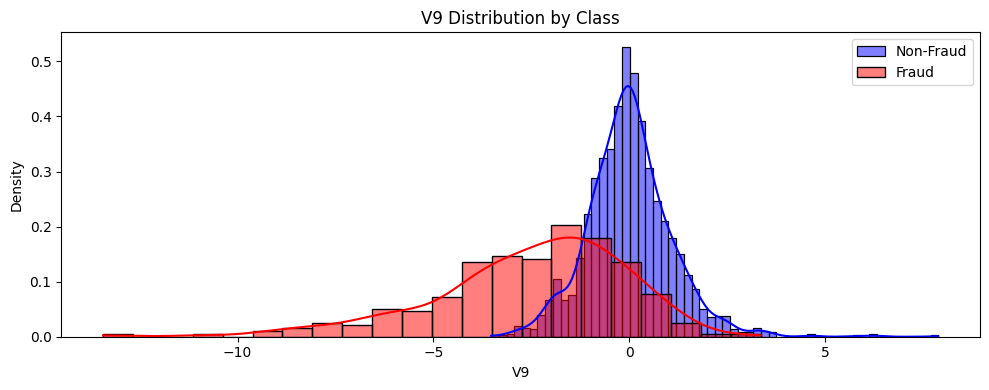

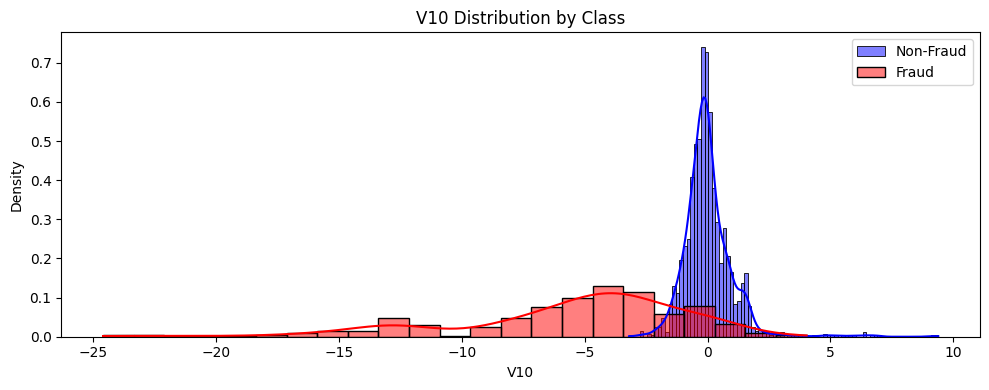

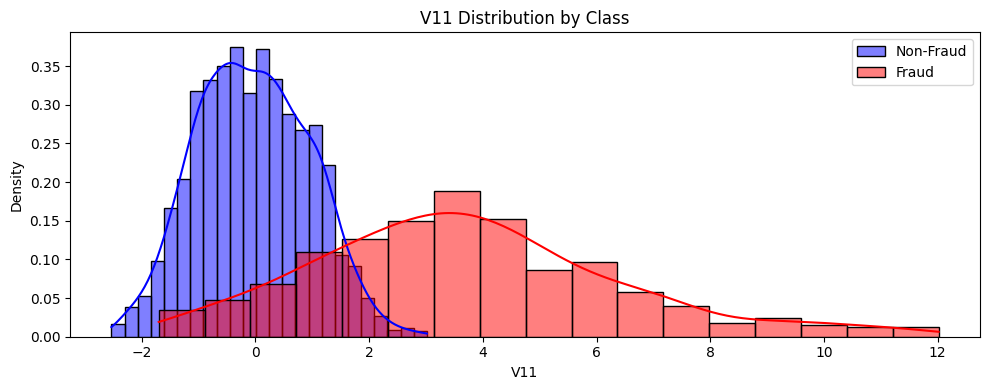

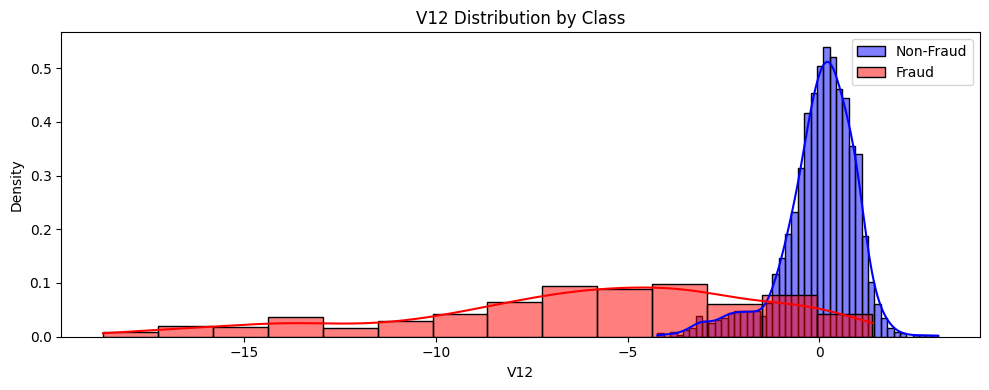

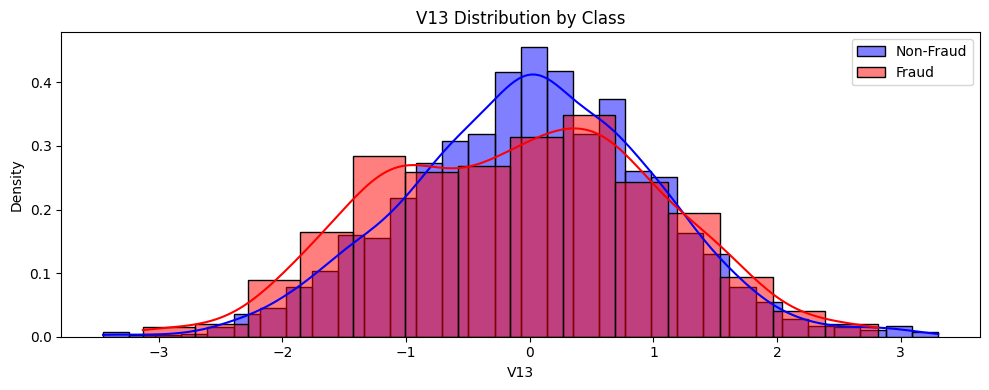

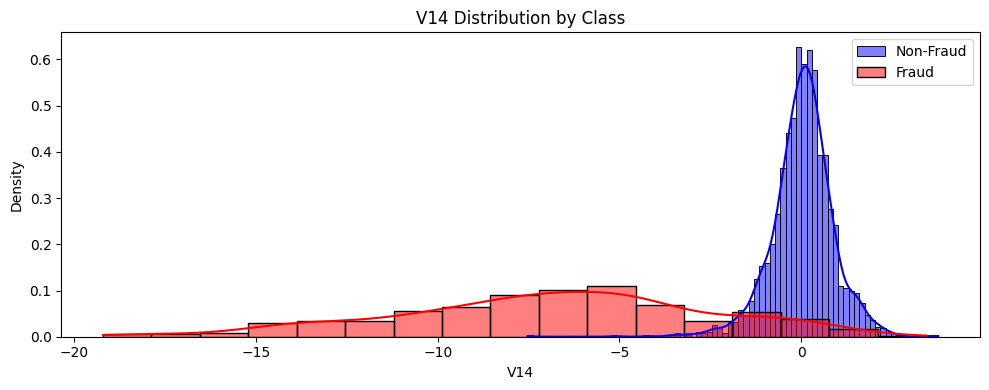

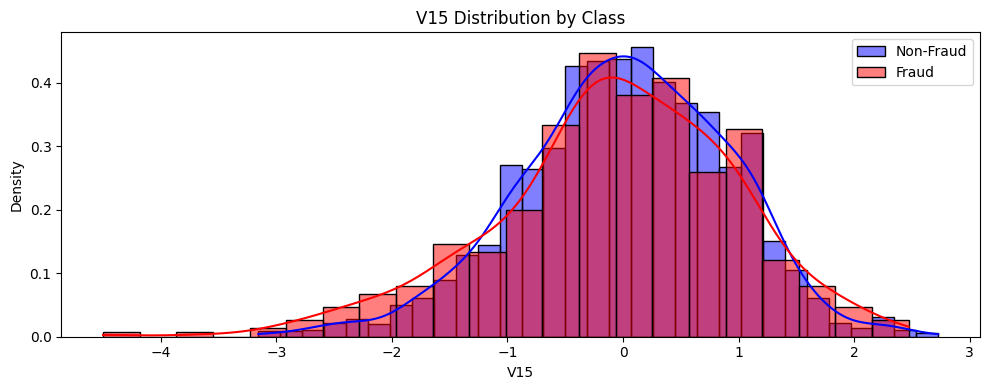

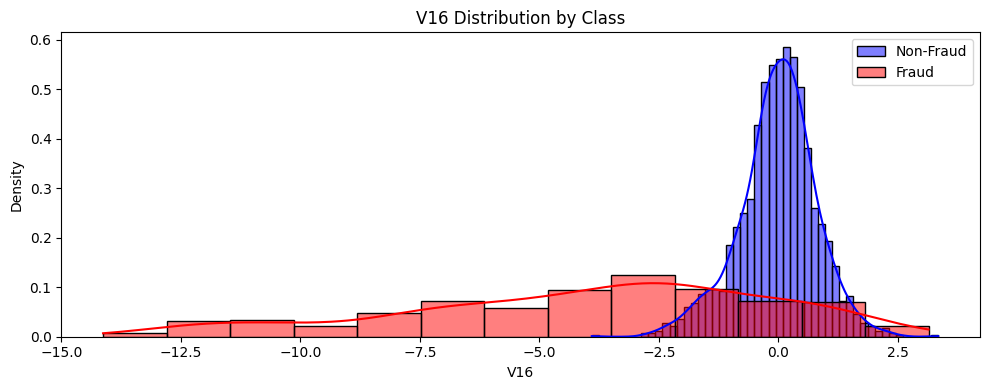

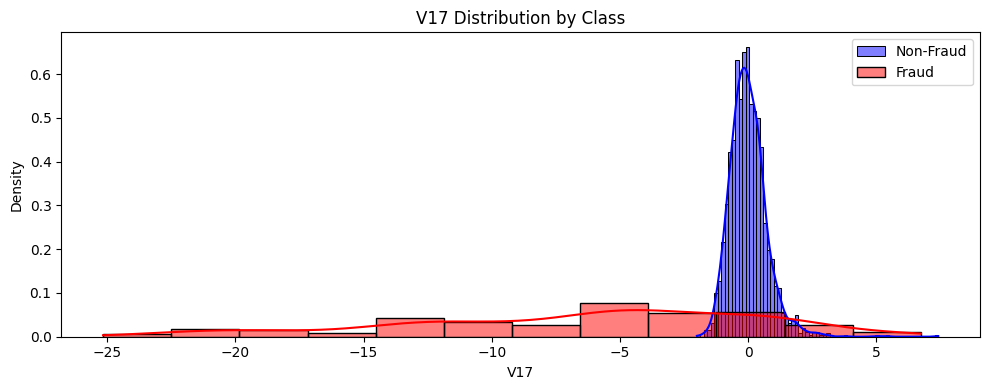

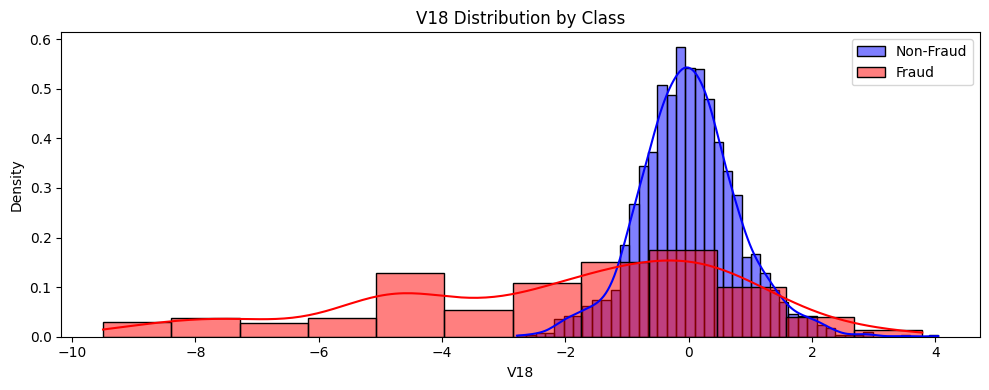

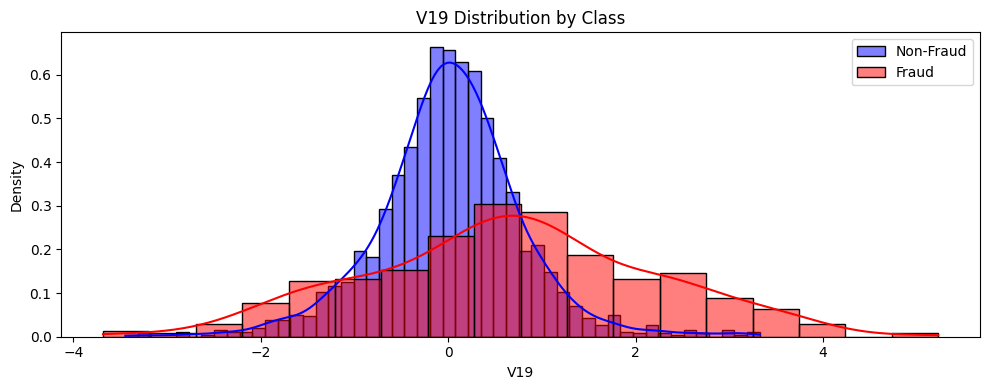

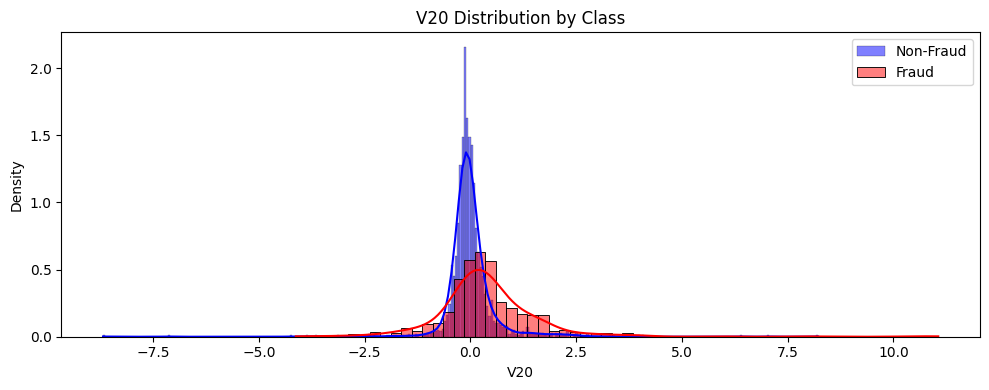

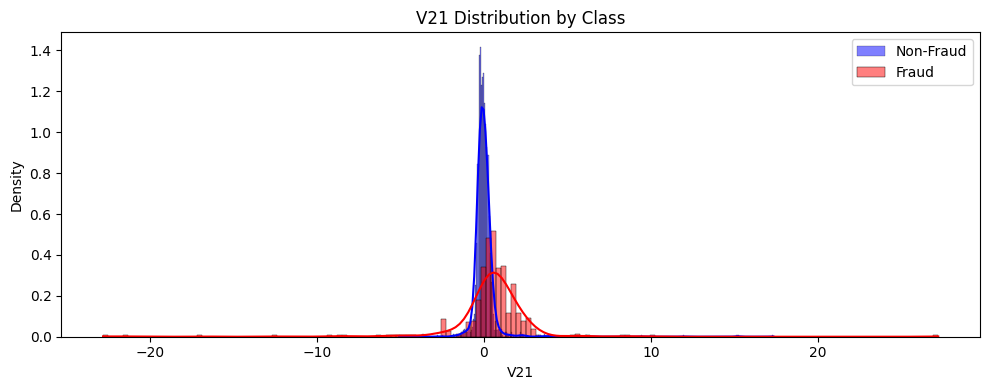

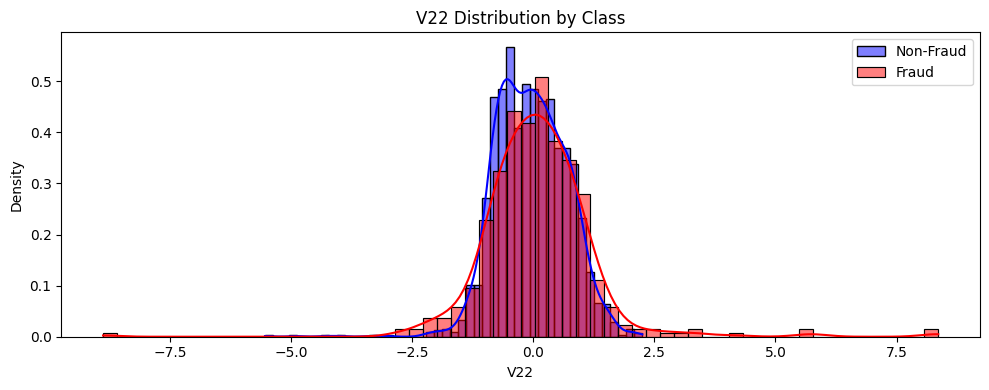

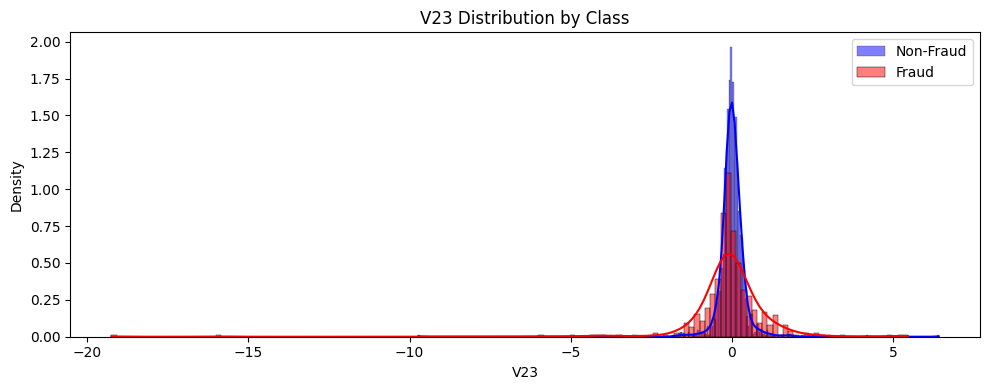

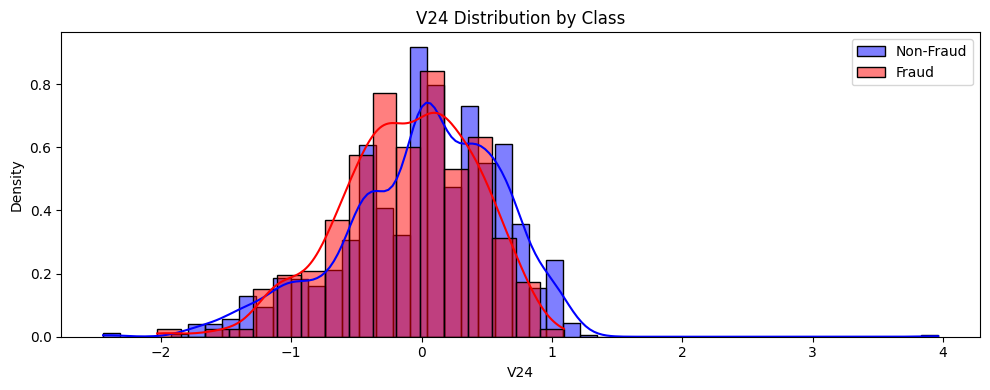

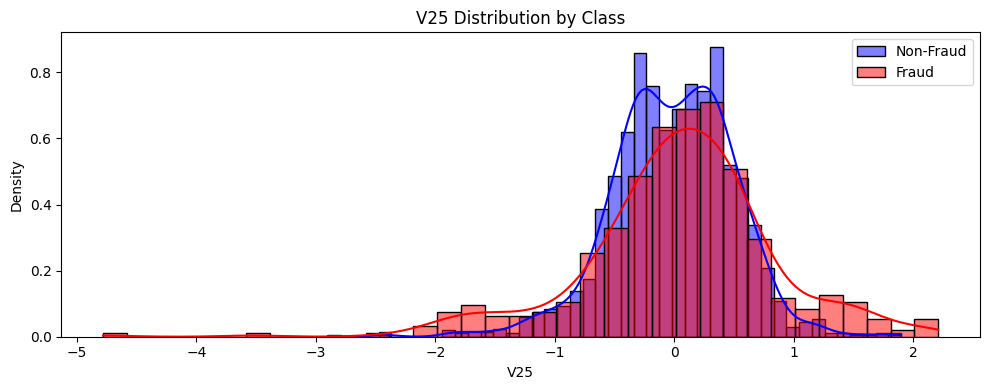

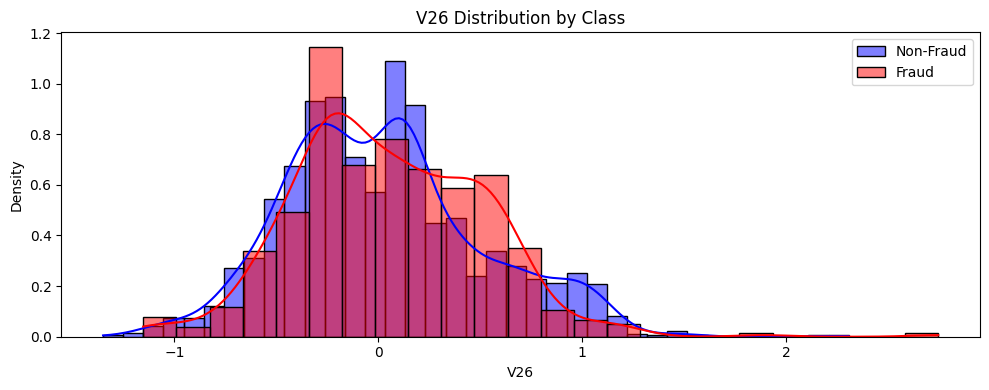

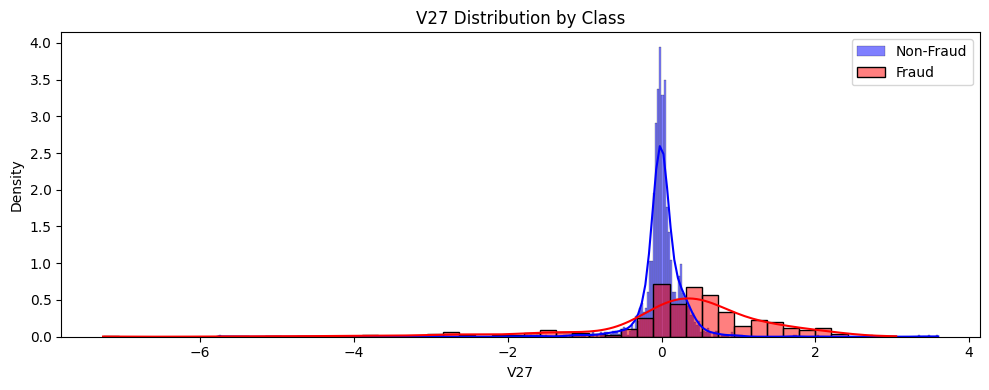

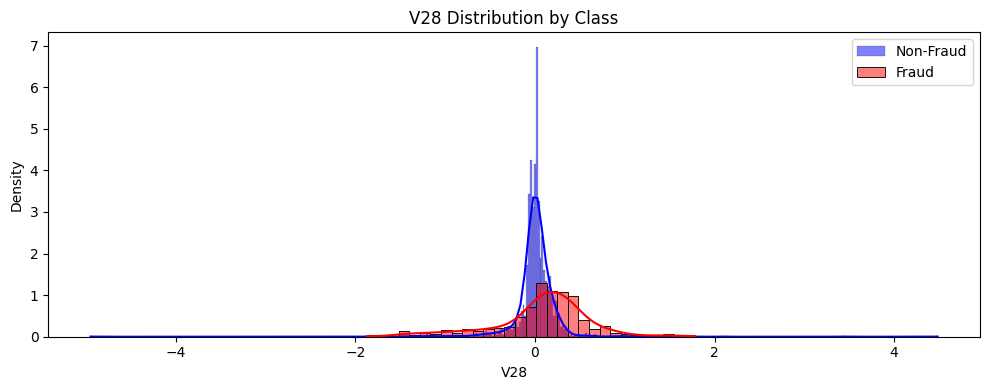

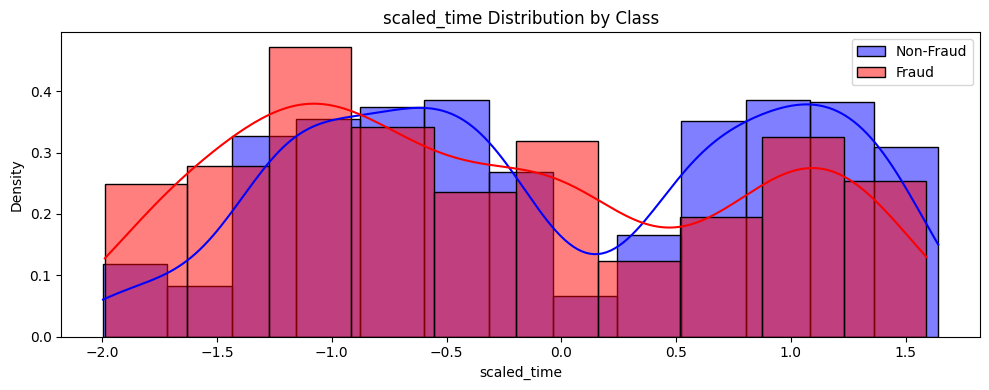

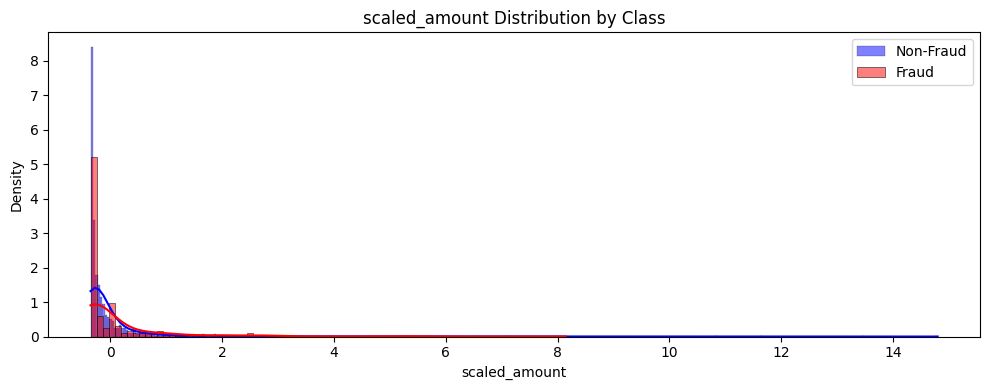

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in X_resampled.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(X_resampled[feature][y_resampled == 0], color="blue", label="Non-Fraud", kde=True, stat="density")
    sns.histplot(X_resampled[feature][y_resampled == 1], color="red", label="Fraud", kde=True, stat="density")
    plt.title(f'{feature} Distribution by Class')
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


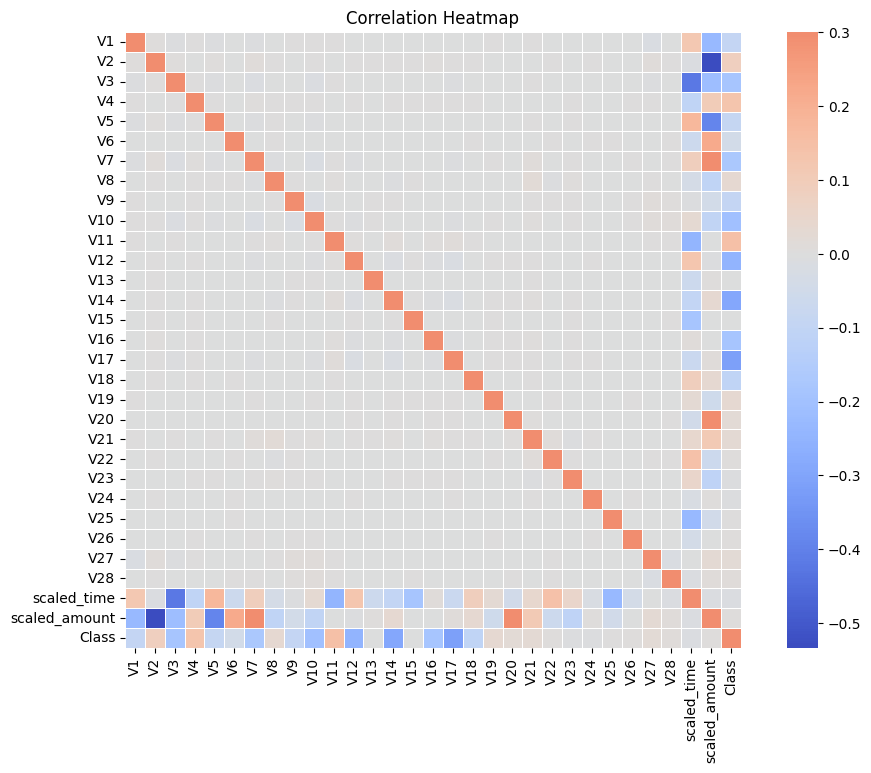

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', vmax=0.3, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


FEATURE SELECTION

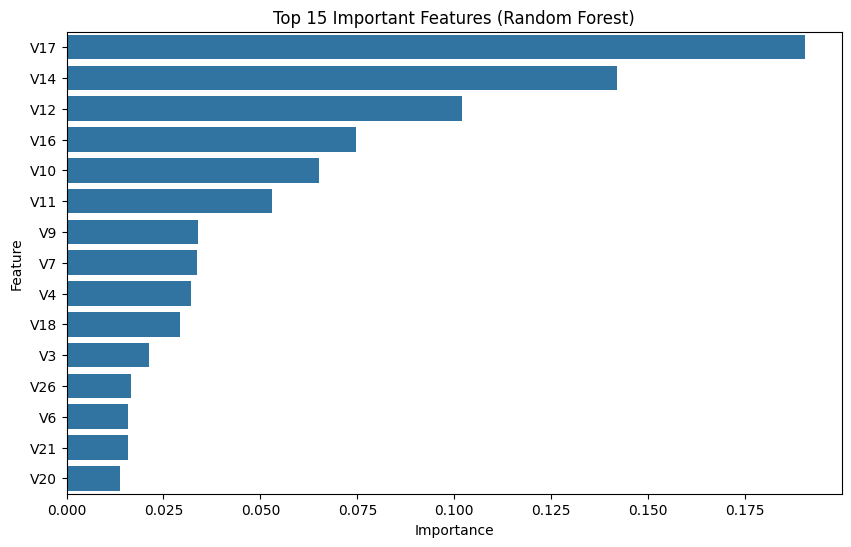

In [ ]:
#Random Forest	(Embedded)	:Handles feature ranking during training

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns

# Create a dataframe
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Important Features (Random Forest)')
plt.show()


In [ ]:
#ANOVA F-test	(Filter)	: Simple statistical test for numeric features
from sklearn.feature_selection import f_classif, SelectKBest

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-score': selector.scores_
}).sort_values(by='F-score', ascending=False)

print(anova_df.head(15))


   Feature       F-score
16     V17  26015.046430
13     V14  22719.847335
11     V12  15743.926556
9      V10  10643.554088
15     V16   8530.799465
2       V3   8396.114493
6       V7   7686.204604
10     V11   5376.453712
3       V4   3884.722043
17     V18   2633.760627
0       V1   2182.755012
8       V9   2099.139575
4       V5   1935.741488
1       V2   1750.568219
5       V6    455.235181


#MODEL 1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train_dt, y_train_dt)
y_pred_dt = dt.predict(X_test_dt)

accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt, average='binary')
recall_dt = recall_score(y_test_dt, y_pred_dt, average='binary')
f1_dt = f1_score(y_test_dt, y_pred_dt, average='binary')

print(f'Decision Tree Accuracy: {accuracy_dt:.2f}')
print(f'Decision Tree Precision: {precision_dt:.2f}')
print(f'Decision Tree Recall: {recall_dt:.2f}')
print(f'Decision Tree F1-score: {f1_dt:.2f}')

print('\nClassification Report:')
print(classification_report(y_test_dt, y_pred_dt))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test_dt, y_pred_dt))


Decision Tree Accuracy: 0.95
Decision Tree Precision: 0.93
Decision Tree Recall: 0.83
Decision Tree F1-score: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       378
           1       0.93      0.83      0.88        95

    accuracy                           0.95       473
   macro avg       0.94      0.91      0.92       473
weighted avg       0.95      0.95      0.95       473


Confusion Matrix:
[[372   6]
 [ 16  79]]


 visulize DecisionTree

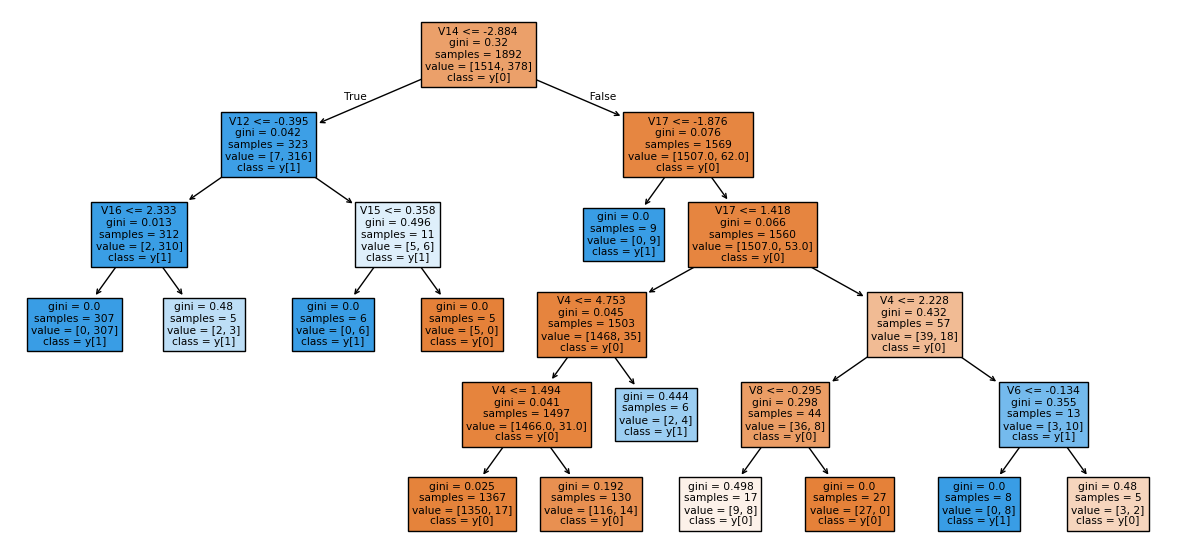

In [ ]:
plt.figure(figsize=(15, 7))
plot_tree(dt, filled=True, feature_names=X_resampled.columns, class_names=True)
plt.show()

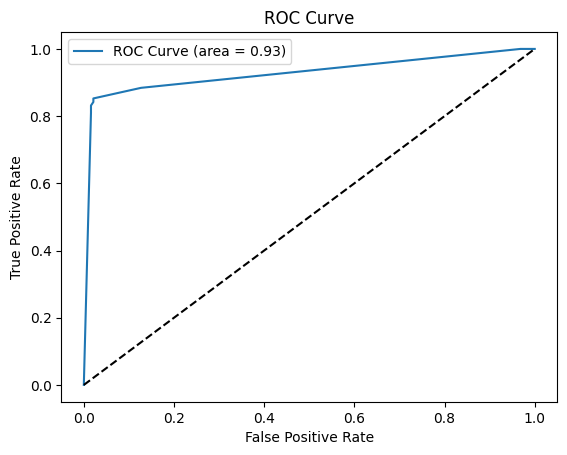

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_proba = dt.predict_proba(X_test_dt)[:, 1]  # احتمالات الكلاس الإيجابي
fpr, tpr, _ = roc_curve(y_test_dt, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


lofo

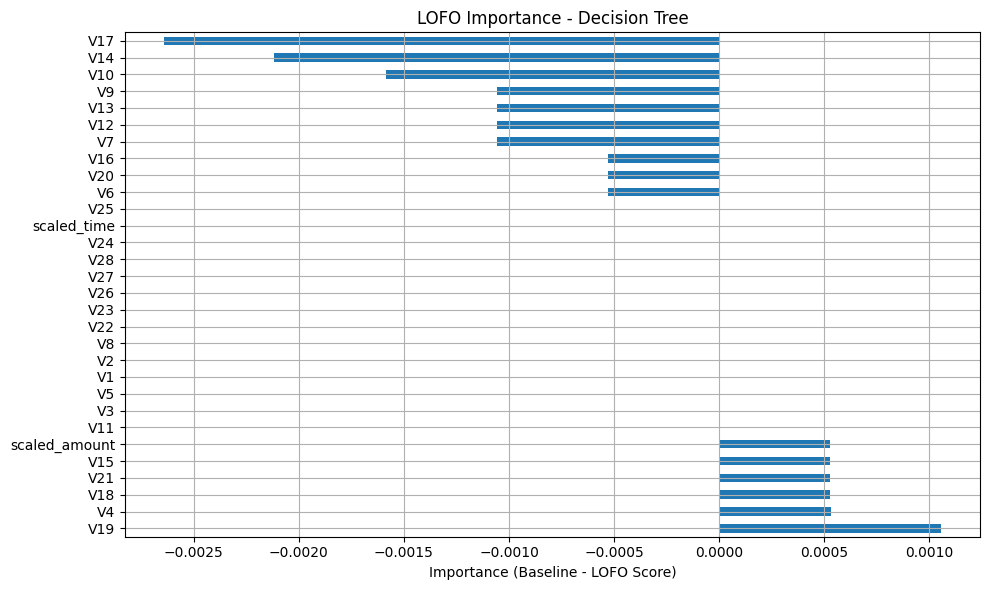

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier


feature_names = X_train_dt.columns.tolist()
X_train_dt_df = X_train_dt.copy()

baseline = cross_val_score(
    dt,
    X_train_dt_df,
    y_train_dt,
    cv=5,
    scoring='accuracy'
).mean()

lofo_scores_dt = {}
for col in X_train_dt_df.columns:
    X_lofo = X_train_dt_df.drop(columns=[col])
    score = cross_val_score(
        dt,
        X_lofo,
        y_train_dt,
        cv=5,
        scoring='accuracy'
    ).mean()
    lofo_scores_dt[col] = baseline - score

lofo_df_dt = pd.Series(lofo_scores_dt).sort_values(ascending=False)
lofo_df_dt.plot(kind='barh', figsize=(10, 6))
plt.xlabel("Importance (Baseline - LOFO Score)")
plt.title("LOFO Importance - Decision Tree")
plt.grid(True)
plt.tight_layout()
plt.show()

LIME

In [ ]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=487adde79b9a18077b1d2acc4bc81924f011829cdee99fc293c7e2b4f04e4ee9
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np


X_sample = X_test_dt.to_numpy()
y_sample = y_test_dt.to_numpy()

explainer = LimeTabularExplainer(
    training_data=X_train_dt.to_numpy(),
    feature_names=X_train_dt.columns.tolist(),
    class_names=["Non-Fraud", "Fraud"],
    mode='classification',
    discretize_continuous=True
)

def predict_proba_wrapper_dt(x):
    return dt.predict_proba(x)

i = 0
exp = explainer.explain_instance(
    data_row=X_sample[i],
    predict_fn=predict_proba_wrapper_dt,
    num_features=10
)

exp.show_in_notebook(show_table=True, show_all=False)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


pdp

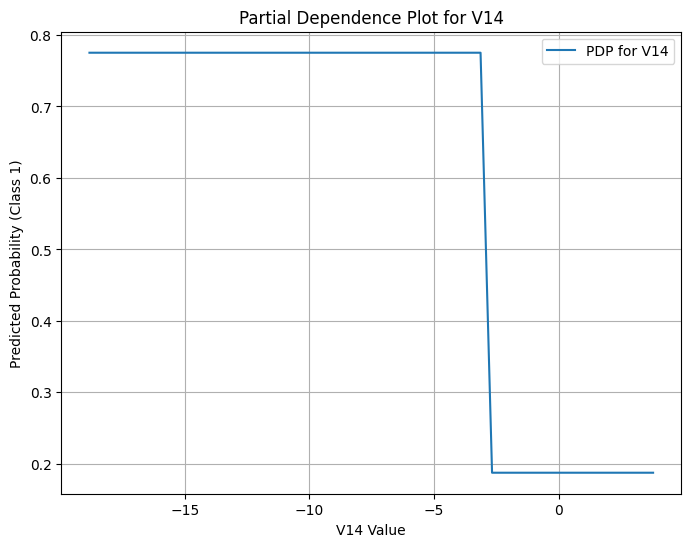

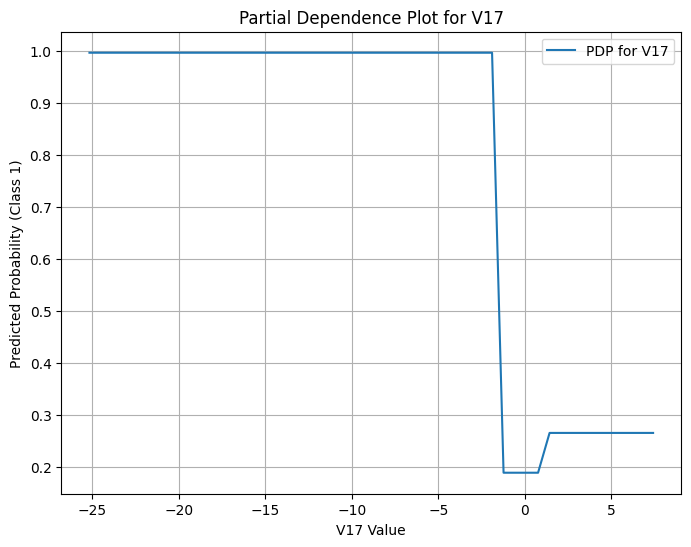

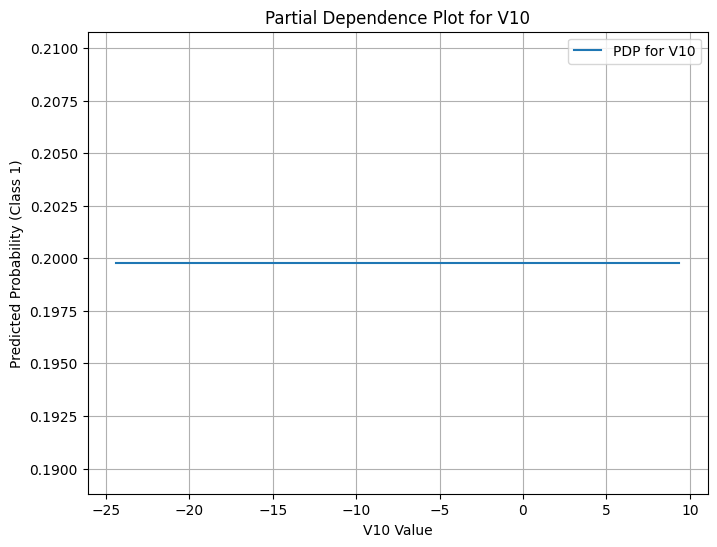

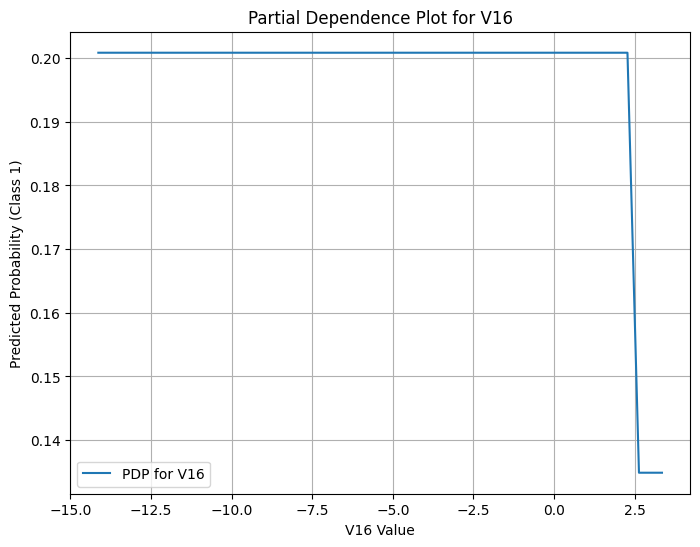

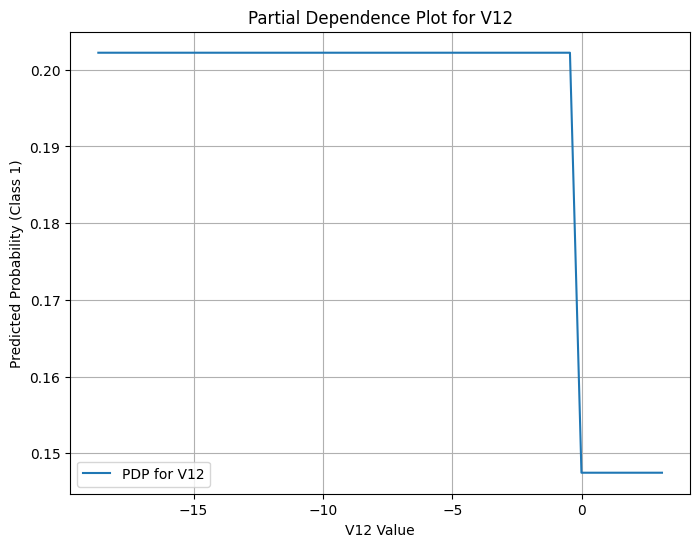

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def tree_predict_fn(X):
    return dt.predict_proba(X)[:, 1]

features_to_plot = ['V14', 'V17', 'V10', 'V16', 'V12']

if isinstance(X_train_dt, pd.DataFrame):
    for feature_name in features_to_plot:
        if feature_name not in X_train_dt.columns:
            print(f"Warning: {feature_name} not found in data.")
            continue

        feature_values = np.linspace(
            X_train_dt[feature_name].min(),
            X_train_dt[feature_name].max(),
            50
        )
        X_mod = X_train_dt.copy()
        pdp_values = []

        for val in feature_values:
            X_mod[feature_name] = val
            preds = tree_predict_fn(X_mod)
            pdp_values.append(np.mean(preds))
        plt.figure(figsize=(8, 6))
        plt.plot(feature_values, pdp_values, label=f"PDP for {feature_name}")
        plt.xlabel(f"{feature_name} Value")
        plt.ylabel("Predicted Probability (Class 1)")
        plt.title(f"Partial Dependence Plot for {feature_name}")
        plt.legend()
        plt.grid(True)
        plt.show()
else:
    print("Error: X_train_dt is not a pandas DataFrame. PDP loop requires column names.")


pfi

In [ ]:
import shap

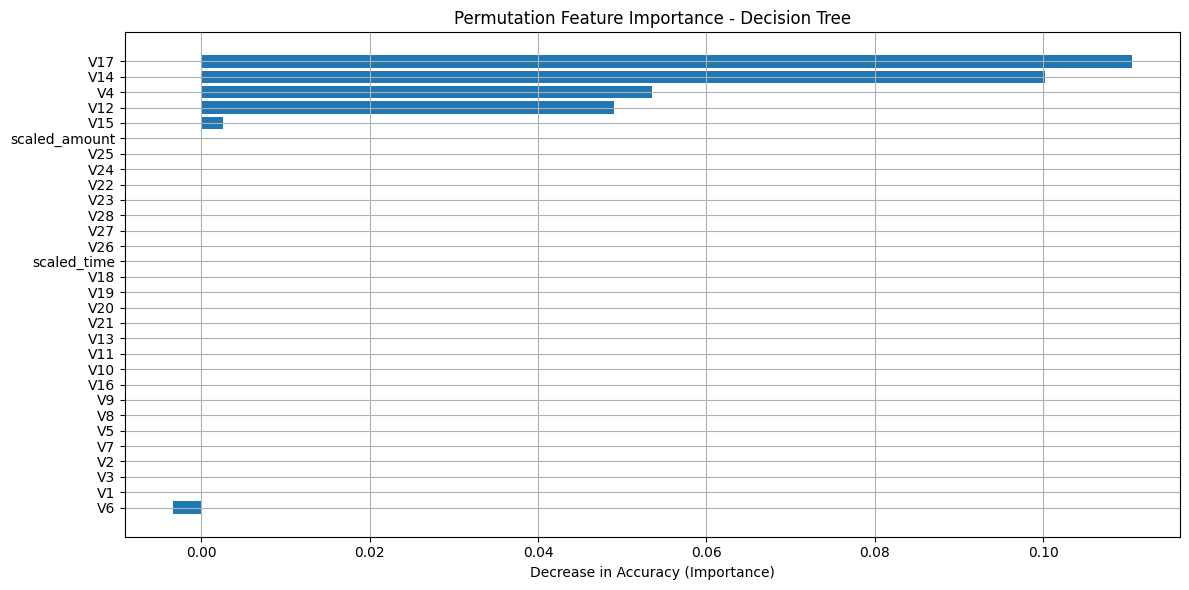

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(
    dt,
    X_test_dt,
    y_test_dt,
    scoring='accuracy',
    n_repeats=10,
    random_state=42
)
sorted_idx = result.importances_mean.argsort()


plt.figure(figsize=(12, 6))
plt.barh(X_test_dt.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Decrease in Accuracy (Importance)")
plt.title("Permutation Feature Importance - Decision Tree")
plt.grid(True)
plt.tight_layout()
plt.show()
